In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.spatial import Voronoi, distance_matrix
import os
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams["figure.dpi"]=300                  
rcParams['mathtext.fontset'] = 'cm'

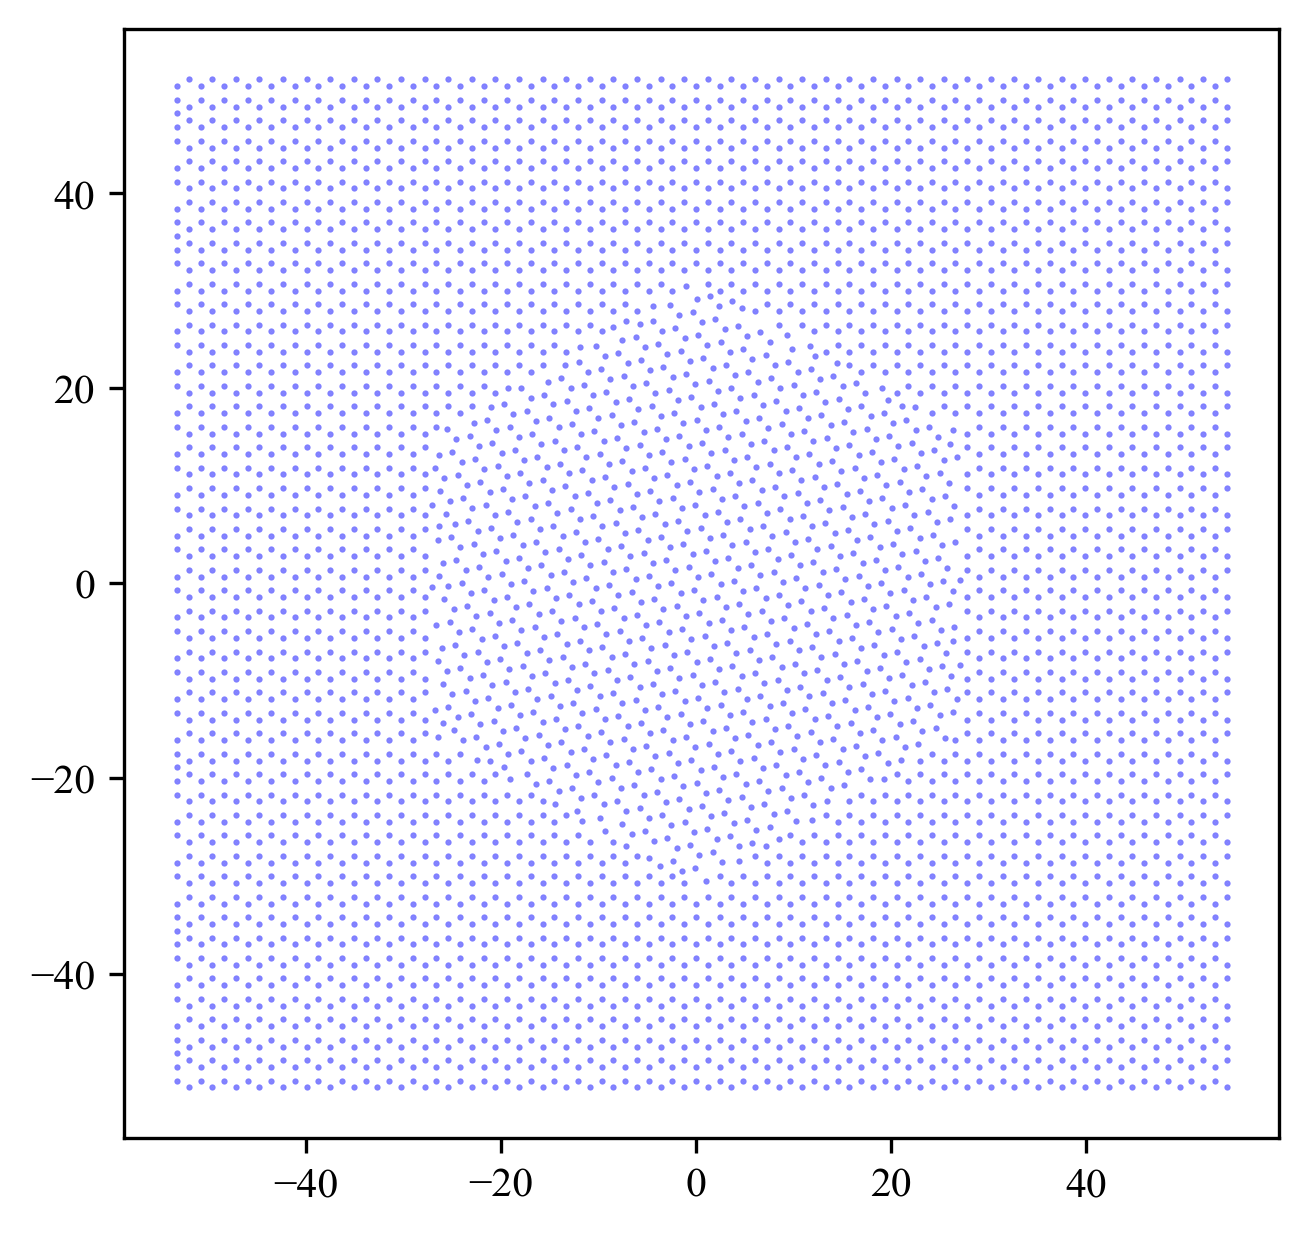

In [7]:
class GBStruct:
    a0=1.3967512290507305
    
    def __init__(self,hex=19,N=20,theta=0,unfreeze_distance=3):
        
        self.N=N # number of unit cells in the initial graphene lattice
        self.hex=hex #size of the hexagonal grain in the center, in A
        self.unfreeze=unfreeze_distance*self.a0 #distance from the grain boundary to select atoms for unfreezing in MD
        
        self.theta=theta*np.pi/180
    def _gen_grp0(self):
        """generator of initial graphene lattice"""
        x0=-round(self.N*3*self.a0/2/(3**0.5*self.a0))*3**0.5*self.a0
        grp=[]
        dx=3**0.5*self.a0/2
        while x0<round(self.N*3*self.a0/2/(3**0.5*self.a0))*3**0.5*self.a0:
            y0=-self.N/2*3*self.a0+self.a0/2
            while y0<self.N/2*3*self.a0:
                grp.append([x0+dx,y0])
                grp.append([x0,y0+self.a0/2])
                grp.append([x0,y0+3*self.a0/2])
                grp.append([x0+dx,y0+2*self.a0])
                y0+=3*self.a0
            x0+=2*dx
        grp=np.array(grp)
        self.lattice=[grp[:,0].max()-grp[:,0].min()+self.a0*3**0.5/2,grp[:,1].max()-grp[:,1].min()+self.a0]
        return grp
    def assemble_struct(self):
        grp=self._gen_grp0() #initial graphene lattice
        len0=len(grp)
        R=lambda t:np.array([[np.cos(t),-np.sin(t)],[np.sin(t),np.cos(t)]])
        """Voronoi vertices and centers for 7 grains: 
        central at (0,0) and 6 0 deg rotated around it"""
        x1=0
        x2=self.hex*3**0.5/2
        y1=self.hex
        y2=self.hex/2
        vertices=[[[-x2,-y2],[-x2,y2]],
                  [[-x2,y2],[x1,y1]],
                  [[x1,y1],[x2,y2]],
                  [[x2,y2],[x2,-y2]],
                  [[x2,-y2],[x1,-y1]],
                  [[x1,-y1],[-x2,-y2]]]
        vertices=np.array(vertices)
        suppl_centers=np.array([[0,0],
                       [self.hex*3**0.5,0],
                       [-self.hex*3**0.5,0],
                       [self.hex*3**0.5/2,-1.5*self.hex],
                       [-self.hex*3**0.5/2,-1.5*self.hex],
                       [self.hex*3**0.5/2,1.5*self.hex],
                       [-self.hex*3**0.5/2,1.5*self.hex],])
        
        dm_out=distance_matrix(grp,suppl_centers)# find atoms in outer region
        mask=np.zeros(len(dm_out))
        for i in range(6):
            mask+=(dm_out[:,0]>dm_out[:,1+i])
        indxs=np.where(mask)
        grp1=np.dot(grp,R(self.theta)) #rotate
        grp=grp[indxs]
        dm_out=distance_matrix(grp1,suppl_centers)  # find atoms in inner region
        mask=np.ones(len(dm_out))
        for i in range(6):
            mask*=(dm_out[:,0]<dm_out[:,1+i])
        indxs=np.where(mask)
        grp1=grp1[indxs]
        struct_fin=np.concatenate([grp,grp1])
        dm=distance_matrix(struct_fin,struct_fin)
        dm+=np.eye(len(struct_fin))*10
        mask=np.where(dm<self.a0*0.8) #remove atoms that are too close to each other
        xy1=[]
        for i,c in enumerate(struct_fin):
            if i in mask[0]:
                ii=np.where(mask[0]==i)[0][0]
                j=mask[1][ii]
                if i<j:
                    c=(c+struct_fin[j])/2
                    xy1.append(c)
            else:
                xy1.append(c)
        struct_fin=np.array(xy1)
        dN=len0-len(struct_fin) #if density is too low, add atoms in the gaps
        if dN>0:
            addat=self.fill_the_gaps(struct_fin,addat=dN)
            struct_fin=np.concatenate([struct_fin,addat])
        unfreeze_indxs=[] #select atoms that are close to the grain boundaries to be unfrozen for MD
        for v in vertices:
            unfreeze_indxs.append(self.proximity_indxs(struct_fin,v))
        unfreeze_indxs=np.concatenate(unfreeze_indxs)
        unfreeze_indxs=np.unique(unfreeze_indxs)
        self.unfreeze_indxs=unfreeze_indxs
        return struct_fin
    def fill_the_gaps(self,xy,addat=10):
        sigma=self.a0/2
        dx=self.a0/4
        x=np.arange(xy[:,0].min(),xy[:,0].max(),dx)
        y=np.arange(xy[:,1].min(),xy[:,1].max(),dx)
        x,y=np.meshgrid(x,y)
        z=np.zeros(x.shape)
        for c in xy:
            z+=np.exp(-((c[0]-x)**2+(c[1]-y)**2)/(2*sigma**2))
        added=[]
        for a in range(addat):
            ii=np.unravel_index(np.argmin(z, axis=None), z.shape)
            added.append([x[ii],y[ii]])
            z+=np.exp(-((x[ii]-x)**2+(y[ii]-y)**2)/(2*sigma**2))

        return np.array(added)

    def proximity_indxs(self,xy,line):
        #finding equation of line: ax+by+c=0
        if line[0,0]==line[1,0]:
            b=0
            a=1
            c=-line[0,0]
        else:
            b=1
            a=(line[1,1]-line[0,1])/(line[0,0]-line[1,0])
            c=-a*line[0,0]-b*line[0,1]
        mask=np.ones(len(xy))
        mask*=((line[:,0].max()+self.unfreeze)>xy[:,0])
        mask*=((line[:,0].min()-self.unfreeze)<xy[:,0])
        mask*=((line[:,1].max()+self.unfreeze)>xy[:,1])
        mask*=((line[:,1].min()-self.unfreeze)<xy[:,1])

        indxs_of_interest=np.where(mask)[0]
        
        xy1=xy[indxs_of_interest]
        d=np.abs(a*xy1[:,0]+b*xy1[:,1]+c)/(a**2+b**2)**0.5
        indxs=np.where(d<self.unfreeze)[0]

        return indxs_of_interest[indxs]

s=GBStruct(hex=31,N=25,theta=17)

grp=s.assemble_struct()

plt.plot(grp[:,0],grp[:,1],'b.',alpha=0.5,markersize=1)
plt.gca().set_aspect('equal')


In [5]:
lammps_command='mpiexec -np 4 ~/Downloads/lammps-29Aug2024/build/lmp'
class MD_airebo:
    types_dict={1:'H',6:'C',8:'O'}
    at_dict={'H':1,'C':6,'O':8}
    def __init__(self):
        self.xyz=[]
        self.types=[]
        self.size=[]
        self.E=None
        
    def read_xyz(self,fname):
        with open(fname) as f:
            lines=f.readlines()
        types=[]
        xyz=[]
        for l in lines[::-1]:
            l=l.split()
            if len(l)<4:
                break
            types.append(self.at_dict[l[0]])
            x=float(l[1])
            y=float(l[2])
            z=float(l[3])
            xyz.append([x,y,z])
        self.xyz=np.array(xyz)
        self.types=np.array(types,dtype=np.int32)
        print(f'C{(self.types==6).sum()} O{(self.types==8).sum()} H{(self.types==1).sum()}')
    def read_lmp_out_coords(self,fname):
        f=open(fname)
        lines=f.readlines()
        f.close()
        xyz=[]
        i=-1
        while not 'ITEM' in lines[i]:
            line=lines[i]
            _,_,x,y,z=map(float,line.split())
            xyz.append([x,y,z])
            i-=1
        i-=1
        #self.size=float(lines[i].split()[1])*2
        self.xyz=np.array(xyz)[::-1]
    def read_lmp_out(self,fname):
        f=open(fname,'r')
        lines=f.readlines()
        f.close()
        i=-1
        while (i>-len(lines)) and ('Energy' not in lines[i]):
            i-=1
        if 'Energy' in lines[i]:
            self.E = float(lines[i+1].split()[-1])
        else:
            self.E=None

    def gen_input(self,name,flat=True,unfreeze_indxs=None):
        f=open(name+'_2d.inp','w')
        f.write('units metal\n')
        if flat:
            f.write('dimension 2\n')
        f.write('atom_style atomic\n')
        f.write('boundary p p p\n')
        f.write('newton on\n\n')
        f.write(f'read_data {name.split("/")[-1]}.coord\n\n')
        f.write('pair_style airebo 3.0 \npair_coeff * * CH.airebo C\n')
        #f.write('delete_atoms overlap 0.1 all all\n')
        f.write(f'dump DDump all atom 100 {name.split("/")[-1]}.lammpstrj\n\n')
        f.write(f'timestep 0.0002\nthermo_style multi\nthermo 100\n\n')
        if  unfreeze_indxs is None:
            freeze_name='all'
            unfreeze_name='all'
        else:
            freeze_name='freeze'
            unfreeze_name='unfreeze'
            s='group freeze id'
            s1='group unfreeze id'
            for i in range(len(self.xyz)):
                if i in unfreeze_indxs:
                    s1+=f' {i+1}'
                else:
                    s+=f' {i+1}'
            s+='\n'
            s1+='\n'
            f.write(s)
            f.write(s1)
            f.write(f'fix zeroforce {freeze_name} setforce 0 0 0\n')
            f.write(f'compute myTemp {unfreeze_name} temp\nthermo_modify temp myTemp\n')
        f.write('dump_modify DDump sort id\n')
        f.write('dump_modify DDump scale no\n')
        if flat:
            f.write('fix 4 all enforce2d\n')
            f.write('minimize 1.0e-8 0 5000 1000000\n')
            
            
            
            f.write(f'fix 5 {unfreeze_name} langevin 16500 500 0.02 {np.random.randint(1e6)}\n')
            f.write(f'fix 6 {unfreeze_name} nve\n')
            #f.write(f'fix 5 {unfreeze_name} nvt temp 20000 1 0.02 \n')
            if  freeze_name!='all':
                f.write(f'fix zeroforce {freeze_name} setforce 0 0 0\n')
                f.write('fix 40 all enforce2d\n')
            f.write(f'run 5000\n\n')
        f.write('minimize 1.0e-8 0 5000 1000000\n')
        f.close()
    def gen_input_3d(self,name,unfreeze_indxs=None):
        f=open(name+'_3d.inp','w')
        f.write('units metal\n')

        f.write('atom_style atomic\n')
        f.write('boundary p p p\n')
        f.write('newton on\n\n')
        f.write(f'read_data {name.split("/")[-1]}.coord\n\n')
        f.write('pair_style airebo 3.0 \npair_coeff * * CH.airebo C\n')
        f.write(f'dump DDump all atom 100 {name.split("/")[-1]}_3d.lammpstrj\n')
        f.write('dump_modify DDump sort id\n')
        f.write('dump_modify DDump scale no\n')
        f.write(f'timestep 0.0002\nthermo_style multi\nthermo 100\n\n')
        
        f.write('minimize 1.0e-8 0 5000 1000000\n')
        f.write(f'fix 5 all langevin 500 0 0.02 {np.random.randint(1e6)}\n')
        f.write(f'fix 6 all nve\n')
  
        f.write(f'run 500\n\n')
        
        f.write('minimize 1.0e-8 0 5000 1000000\n')
        f.close()

    def gen_coord_file(self,name):
        
        f=open(name+'.coord','w')
        f.write(name+'\n\n')
        f.write(f'{len(self.xyz)} atoms\n1 atom types\n\n')
        f.write(f'{-self.size[0]/2} {self.size[0]/2} xlo xhi\n')
        f.write(f'{-self.size[1]/2} {self.size[1]/2} ylo yhi\n')
        f.write(f'{-self.size[2]/2} {self.size[2]/2} zlo zhi\n\n')
        f.write('Masses\n\n1 12.0107\n\n')
        f.write('Atoms\n\n')
        i=1
        d={6:1,1:2}
        for c in self.xyz:
            f.write(f'{i}  {1}  {c[0]:.3f}  {c[1]:.3f}  {c[2]:.3f}\n')
            i+=1
        f.close()
        
    def write_in(self,name,flat=True,unfreeze_indxs=None):
        dir=os.path.dirname(name)
        if not os.path.exists(dir):
            os.system(f'mkdir {dir}/')
        os.system(f'cp CH.airebo {dir}/')
        if flat:
            self.gen_input(name,unfreeze_indxs=unfreeze_indxs)
        else:
            self.gen_input_3d(name,unfreeze_indxs=unfreeze_indxs)
        self.gen_coord_file(name)



        
        

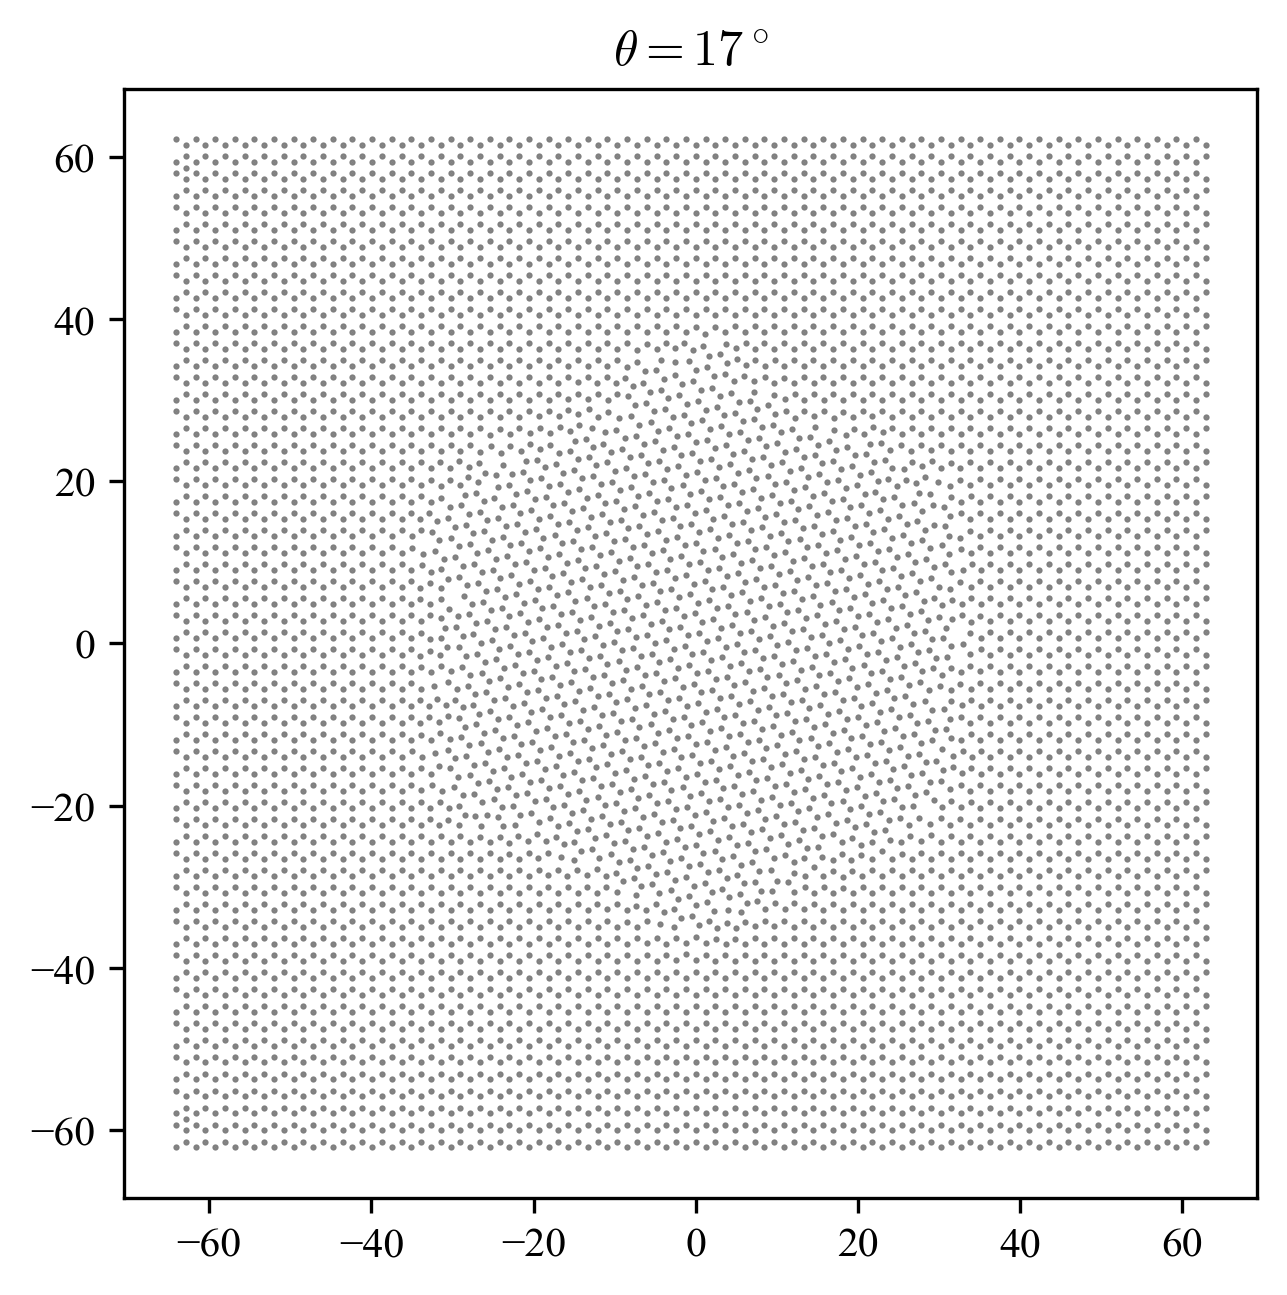

0 -47044.5981586166


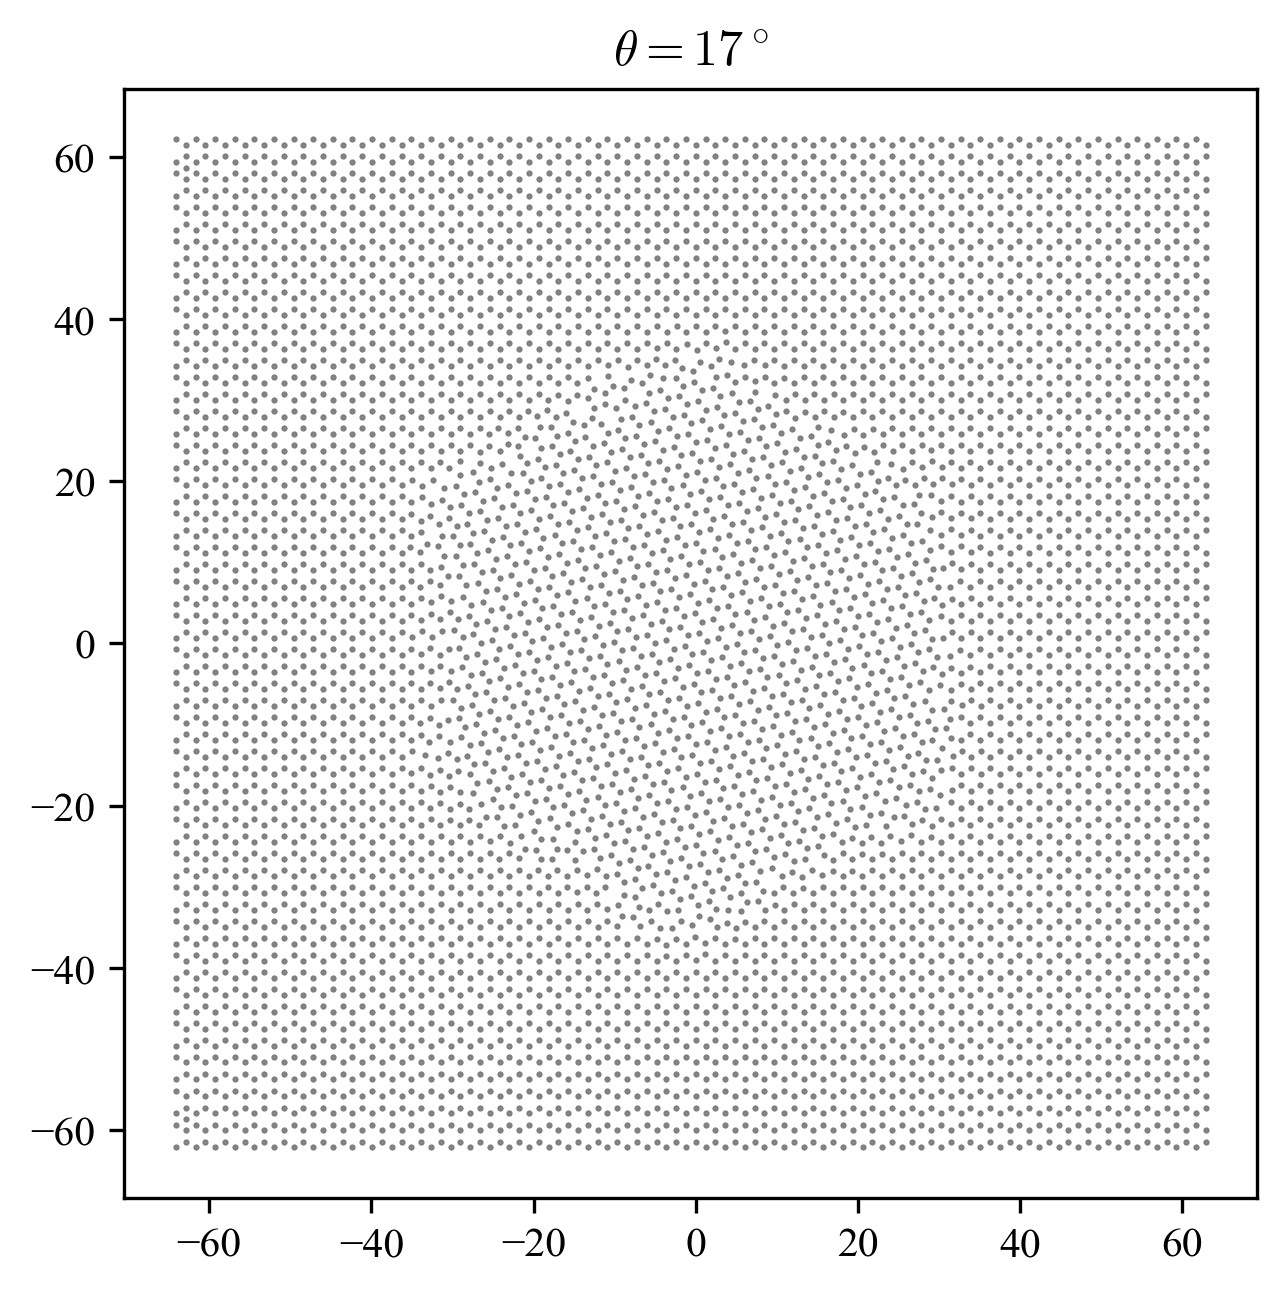

1 -47034.2399000442
theta= 17 	t= 0:02:20.981529 	E= -47039.4190293304 6360


In [6]:
import time
import datetime

for theta in [17]:
    t0=time.time()
    
    dirname=f'gb_potential/theta={theta}/'
    if not os.path.exists(dirname):
        os.system(f'mkdir {dirname}')
    name=f't={theta}'
    s=GBStruct(hex=36,N=30,theta=theta,unfreeze_distance=3)
    xy=s.assemble_struct()
    s.lattice.append(20)
    
    xyz=np.hstack([xy,np.zeros((len(xy),1))])
    
    md=MD_airebo()
    
    en=[]
    for i in range(2):
        md.xyz=xyz
        md.size=s.lattice
        name=f't={theta}_{i}'
        md.write_in(dirname+name,unfreeze_indxs=s.unfreeze_indxs)
        os.system(f'cd {dirname} \n '+lammps_command+ f' -in {name}_2d.inp > {name}.out')
    
        md.read_lmp_out_coords(dirname+name+'.lammpstrj')
        plt.plot(md.xyz[:,0],md.xyz[:,1],'k.',alpha=0.5,markersize=1)
        plt.title(f'$\\theta={theta}^\\circ$')
        plt.gca().set_aspect(1)
        plt.show()
        plt.close()
        
        md.write_in(dirname+name,flat=False)
        os.system(f'cd {dirname} \n '+lammps_command+ f' -in {name}_3d.inp > {name}_3d.out')

        md.read_lmp_out(dirname+name+'_3d.out')
        en.append(md.E)
        print(i,md.E)
    t1=time.time()
    
    print('theta=',theta,'\tt=',datetime.timedelta(seconds=t1-t0),'\tE=',np.mean(en), len(md.xyz))
